# Practica M25

El objetivo de esta actividad es que efectúes un análisis de clasificación mediante Regresión Logística que permita desarrollar un modelo predictivo basado en distintas métricas aplicadas a una base de datos grande.

**Problema:**  

Imagina que eres un investigador médico que recopila datos para un estudio. Has recopilado datos sobre un conjunto de pacientes, todos ellos con la misma enfermedad. Durante su tratamiento, cada paciente ha respondido a uno de los 5 medicamentos, el fármaco A, el fármaco B, el fármaco C (de proveedor nacional), el fármaco X y el Y (de proveedor extranjero). 

Parte de tu trabajo consiste en construir un modelo para averiguar qué medicamento podría ser apropiado para un futuro paciente con la misma enfermedad. Los conjuntos de características de este conjunto de datos son la edad, el sexo, la presión arterial y el colesterol de los pacientes, y el objetivo es estudiar el fármaco al que respondió cada paciente. 

De manera particular para este problema, se requiere saber si el medicamento a aplicar es de origen nacional o extranjero.

* ### Cargue la base de datos “drugs.csv” en Python e investigue cómo convertir las variables predictoras cualitativas de esta base a una escala numérica mediante la instrucción “preprocessing.LabelEncoder()”. Por ejemplo, si una variable tiene 3 posibles categorías, deberá cambiar sus resultados a 0, 1 o 2.

In [1]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('drugs.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [3]:
feature_cols = ['Age','Sex', 'BP', 'Cholesterol','Na_to_K']
X = df[feature_cols]
y = df.Drug

In [4]:
X['Sex'] = X['Sex'].map({'F': 0, 'M': 1})
X['BP'] = X['BP'].map({'LOW': 0, 'NORMAL': 1, 'HIGH': 2})
X['Cholesterol'] = X['Cholesterol'].map({'LOW': 0, 'NORMAL': 1, 'HIGH': 2})

In [5]:
#Creacion de la base de entrenamiento y prueba
x_train,x_test,y_train,y_test = train_test_split(X,y , test_size= 0.2,random_state= 1 )

* ### Use los diversos métodos de optimización para una Regresión Logística vistos en este módulo para encontrar un algoritmo óptimo de clasificación. Explique cuál sería su recomendación para este caso. Regresión Logística 

 **Regresion logistica con Solucionador (Solver): sag**

In [6]:
model = LogisticRegression(solver = 'sag')
clf = model.fit (x_train, y_train)

#Prediccion de etiuquetas de clse sobre datos de prueba
y_pred = model.predict(x_test)
#impresion de coeficientes de la regresion de puntajes
print ('\n intercepto (Beta 0) \n', clf.intercept_, '\n')
print ('pesos de cada varible (Beta1, Beta2, ..., Beta7) \n', clf.coef_, '\n' )
print ('----------------------------------------------------------------')
score = model.score (x_test, y_test)
print ('Precision global: \n', score ) 
print ('----------------------------------------------------------------')
print(classification_report(y_test, y_pred))


 intercepto (Beta 0) 
 [ 0.14374699 -0.12017976  0.06729647  0.41226594 -0.50312964] 

pesos de cada varible (Beta1, Beta2, ..., Beta7) 
 [[-0.03465079  0.13412447  0.92140176  0.19805342 -0.01990037]
 [ 0.05372907 -0.04218207  0.49516699 -0.19981685 -0.25466604]
 [-0.00331175  0.01780326 -0.64516429  0.39553769 -0.02259661]
 [ 0.02114142 -0.04494026 -0.42120058  0.2271736  -0.03927025]
 [-0.03690796 -0.0648054  -0.35020388 -0.62094787  0.33643326]] 

----------------------------------------------------------------
Precision global: 
 0.65
----------------------------------------------------------------
              precision    recall  f1-score   support

       drugA       1.00      0.25      0.40         4
       drugB       0.33      0.50      0.40         2
       drugC       0.00      0.00      0.00         4
       drugX       0.62      0.62      0.62        13
       drugY       0.70      0.94      0.80        17

    accuracy                           0.65        40
   macro

 ** **Regresion logistica con Solucionador (Solver): newton-cg** **

In [7]:
model = LogisticRegression(solver = 'newton-cg')
clf = model.fit (x_train, y_train)

#Prediccion de etiuquetas de clse sobre datos de prueba
y_pred = model.predict(x_test)
#impresion de coeficientes de la regresion de puntajes
print ('\n intercepto (Beta 0) \n', clf.intercept_, '\n')
print ('pesos de cada varible (Beta1, Beta2, ..., Beta7) \n', clf.coef_, '\n' )
print ('----------------------------------------------------------------')
score = model.score (x_test, y_test)
print ('Precision global: \n', score ) 
print ('----------------------------------------------------------------')
print(classification_report(y_test, y_pred))


 intercepto (Beta 0) 
 [  8.5192424   -2.49092556   9.8983593   14.5341824  -30.46085853] 

pesos de cada varible (Beta1, Beta2, ..., Beta7) 
 [[-0.07108225  0.17707539  2.47016325 -0.05927334 -0.61646323]
 [ 0.12470894 -0.04480427  1.98322065 -0.70922479 -0.35711225]
 [-0.0242158  -0.11345624 -3.10613522  1.69350258 -0.64465106]
 [-0.01521981 -0.43291526 -1.30412876 -0.65783482 -0.68858532]
 [-0.0141911   0.41410038 -0.04311991 -0.26716963  2.30681182]] 

----------------------------------------------------------------
Precision global: 
 0.975
----------------------------------------------------------------
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         4
       drugB       1.00      1.00      1.00         2
       drugC       1.00      1.00      1.00         4
       drugX       1.00      0.92      0.96        13
       drugY       0.94      1.00      0.97        17

    accuracy                           0.97        40
  

 **Regresion logistica con Solucionador (Solver): liblinear**

In [8]:
model = LogisticRegression(solver = 'liblinear')
clf = model.fit (x_train, y_train)

#Prediccion de etiuquetas de clse sobre datos de prueba
y_pred = model.predict(x_test)
#impresion de coeficientes de la regresion de puntajes
print ('\n intercepto (Beta 0) \n', clf.intercept_, '\n')
print ('pesos de cada varible (Beta1, Beta2, ..., Beta7) \n', clf.coef_, '\n' )
print ('----------------------------------------------------------------')
score = model.score (x_test, y_test)
print ('Precision global: \n', score ) 
print ('----------------------------------------------------------------')
print(classification_report(y_test, y_pred))


 intercepto (Beta 0) 
 [-0.05372801 -1.68713298 -0.00645855  2.67706643 -3.90888842] 

pesos de cada varible (Beta1, Beta2, ..., Beta7) 
 [[-0.074427    0.16219676  3.35794016  0.77079144 -0.43508484]
 [ 0.064767   -0.46847081  1.66494991 -0.81092536 -0.36830976]
 [-0.01647263 -0.06769618 -2.62309281  2.10466289 -0.29830975]
 [ 0.01656305 -0.42969409 -0.89484946  0.16177031 -0.27677331]
 [-0.03487388  0.05366096 -0.38274701 -1.32710465  0.53575248]] 

----------------------------------------------------------------
Precision global: 
 0.775
----------------------------------------------------------------
              precision    recall  f1-score   support

       drugA       1.00      0.50      0.67         4
       drugB       0.67      1.00      0.80         2
       drugC       1.00      0.25      0.40         4
       drugX       0.75      0.69      0.72        13
       drugY       0.77      1.00      0.87        17

    accuracy                           0.78        40
   macr

 **Regresion logistica con Solucionador (Solver): saga**

In [9]:
model = LogisticRegression(solver = 'saga')
clf = model.fit (x_train, y_train)

#Prediccion de etiuquetas de clse sobre datos de prueba
y_pred = model.predict(x_test)
#impresion de coeficientes de la regresion de puntajes
print ('\n intercepto (Beta 0) \n', clf.intercept_, '\n')
print ('pesos de cada varible (Beta1, Beta2, ..., Beta7) \n', clf.coef_, '\n' )
print ('----------------------------------------------------------------')
score = model.score (x_test, y_test)
print ('Precision global: \n', score ) 
print ('----------------------------------------------------------------')
print(classification_report(y_test, y_pred))


 intercepto (Beta 0) 
 [ 0.08992251 -0.06564483  0.03617445  0.21598927 -0.2764414 ] 

pesos de cada varible (Beta1, Beta2, ..., Beta7) 
 [[-0.03075135  0.08294423  0.56267582  0.13198403  0.02068328]
 [ 0.05460795 -0.02008708  0.28758313 -0.11883619 -0.2565223 ]
 [-0.00343267  0.00858251 -0.35621834  0.21558256 -0.02277846]
 [ 0.02175821 -0.02692372 -0.25938416  0.15419437 -0.03827936]
 [-0.04218214 -0.04451594 -0.23465645 -0.38292478  0.29689685]] 

----------------------------------------------------------------
Precision global: 
 0.65
----------------------------------------------------------------
              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         4
       drugB       0.33      0.50      0.40         2
       drugC       0.00      0.00      0.00         4
       drugX       0.64      0.69      0.67        13
       drugY       0.70      0.94      0.80        17

    accuracy                           0.65        40
   macro

 **Regresion logistica con Solucionador (Solver): lbfgs**

In [10]:
model = LogisticRegression(solver = 'lbfgs')
clf = model.fit (x_train, y_train)

#Prediccion de etiuquetas de clse sobre datos de prueba
y_pred = model.predict(x_test)
#impresion de coeficientes de la regresion de puntajes
print ('\n intercepto (Beta 0) \n', clf.intercept_, '\n')
print ('pesos de cada varible (Beta1, Beta2, ..., Beta7) \n', clf.coef_, '\n' )
print ('----------------------------------------------------------------')
score = model.score (x_test, y_test)
print ('Precision global: \n', score ) 
print ('----------------------------------------------------------------')
print(classification_report(y_test, y_pred))


 intercepto (Beta 0) 
 [ 0.57299591 -0.83221923  0.37062166  2.76850904 -2.87990739] 

pesos de cada varible (Beta1, Beta2, ..., Beta7) 
 [[-7.11017387e-02  2.97098112e-01  3.47431059e+00  4.06745337e-01
  -2.59773896e-01]
 [ 4.92520785e-02 -3.44290290e-01  1.55923132e+00 -7.03731132e-01
  -1.45622957e-01]
 [ 6.35442299e-03 -1.32852140e-02 -3.51034089e+00  2.03698175e+00
  -1.36601411e-01]
 [ 2.91622150e-02 -1.88539304e-01 -1.15193697e+00 -6.86294693e-01
   2.54800353e-03]
 [-1.36669778e-02  2.49016696e-01 -3.71264048e-01 -1.05370126e+00
   5.39450261e-01]] 

----------------------------------------------------------------
Precision global: 
 0.9
----------------------------------------------------------------
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         4
       drugB       1.00      1.00      1.00         2
       drugC       1.00      1.00      1.00         4
       drugX       0.91      0.77      0.83        13
       d

* ### ¿Qué tan eficaz es el algoritmo predictivo escogido? Explique a detalle comentando sobre los indicadores obtenidos mediante el reporte de clasificación correspondiente y la curva ROC.

Se analizaron cinco modelos diferentes: Sag, newton-cg, liblinear, saga y lbfgs. Tras la evaluación de su desempeño, se determinó que el modelo newton-cg fue el que mostró resultados superiores en comparación con los demás modelos considerados.

El **modelo newton-cg** logró una **precisión global del 97%**, destacándose no solo por esta cifra, sino también por su alto desempeño general reflejado en el reporte de clasificación. 

***
# ** CURVA ROC, SOLVER: NEWTON-CG **

La curva ROC reafirma la fiabilidad del modelo, mostrando que todos los medicamentos presentan un área de 1.00, lo que indica una capacidad excelente del modelo para distinguir entre clases. Sin embargo, se observa una excepción en el caso del medicamento X, cuyo área bajo la curva es de 0.99. 
***




drugA: AUC = 1.00
drugB: AUC = 1.00
drugC: AUC = 1.00
drugX: AUC = 0.99
drugY: AUC = 1.00


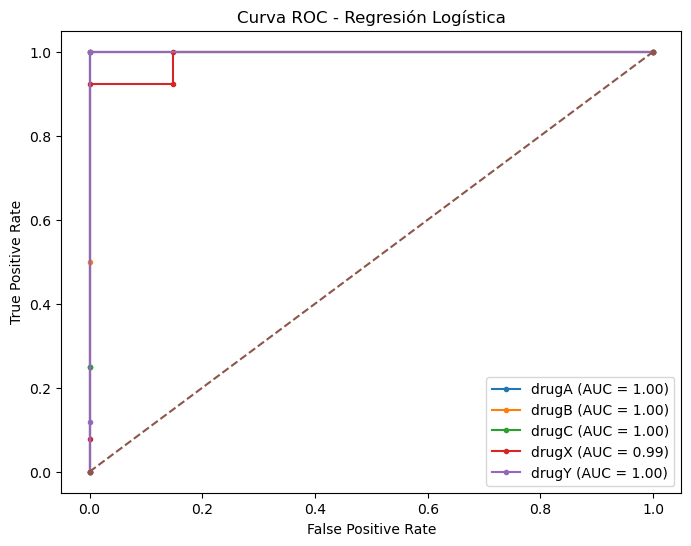

In [15]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import auc

model = LogisticRegression(solver='newton-cg')
clf = model.fit(x_train, y_train)

classes = ['drugA', 'drugB', 'drugC', 'drugX', 'drugY']
y_test_bin = label_binarize(y_test, classes=classes)
y_pred_probs = model.predict_proba(x_test)
plt.figure(figsize=(8, 6))
for i in range(5):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_pred_probs[:, i]
    )
    roc_auc = auc(fpr, tpr)
    print(f'{classes[i]}: AUC = {roc_auc:.2f}')
    plt.plot(
        fpr,
        tpr,
        label=f'{classes[i]} (AUC = {roc_auc:.2f})',
         marker= '.'
    )
plt.plot([0, 1], [0, 1], linestyle='--', marker= '.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Regresión Logística')
plt.legend()
plt.show()